In [1]:
import seaborn as sns 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [3]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
x = df[['total_bill','tip','size']]
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(x)

print("Clustering data ready shape:", X_scaled.shape)

Clustering data ready shape: (244, 3)


In [5]:
df_scaled = pd.DataFrame(X_scaled, columns=['total_bill','tip','size'])
df_scaled.head()

,total_bill,tip,size
0,-0.314711,-1.439947,-0.600193
1,-1.063235,-0.969205,0.453383
2,0.137780,0.363356,0.453383
3,0.438315,0.225754,-0.600193
4,0.540745,0.443020,1.506958


In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Class label (Target) ke liye categorical column chunein (jaise 'day' ya 'time')
y = df['day']

# Agar day me 4 classes hain (Thur, Fri, Sat, Sun), toh max n_components = 3 ho sakta hai
lda = LinearDiscriminantAnalysis(n_components=2)

# df_scaled ka use karein column indexing ke liye
X_lda = lda.fit_transform(df_scaled[['total_bill', 'size','tip']], y)

print("X_lda shape:", X_lda.shape)

X_lda shape: (244, 2)


In [7]:
X_lda[:4]

array([[-0.70210091, -0.40950942],
       [ 0.16644107,  1.59493664],
       [ 0.45033008,  0.27587853],
       [-0.4477698 , -1.04270733]])

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(df_scaled[['total_bill', 'size', 'tip']])

print("X_pca shape:", X_pca.shape)
print(pca.explained_variance_ratio_)

X_pca shape: (244, 2)
[0.72627656 0.1730423 ]


In [9]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(df_scaled[['total_bill', 'size', 'tip']])
print("X_tsne shape:", X_tsne.shape)

X_tsne shape: (244, 2)


In [10]:
X_tsne[:4]

array([[-14.373922 ,   6.5336094],
       [-16.372059 ,  -5.4449444],
       [ 13.22019  ,  -9.786495 ],
       [  0.8790826,   2.0116422]], dtype=float32)

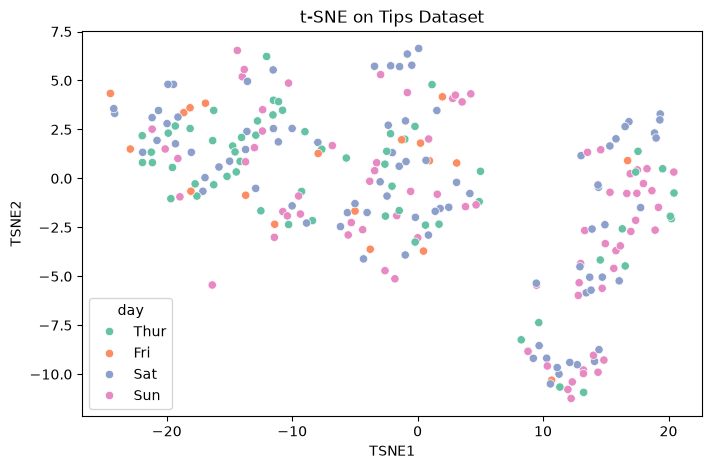

In [11]:
# DataFrame banayein
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['day'] = df['day']

# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='day', palette='Set2')
plt.title('t-SNE on Tips Dataset')
plt.show()

In [13]:
from umap import UMAP
reducer = UMAP(n_components=2)
x = reducer.fit_transform(df_scaled)

In [14]:
x.shape

(244, 2)

In [15]:
x[:4]

array([[5.4216914, 4.3338976],
       [5.6833625, 7.953811 ],
       [4.4921317, 9.578882 ],
       [0.9519864, 2.5119026]], dtype=float32)

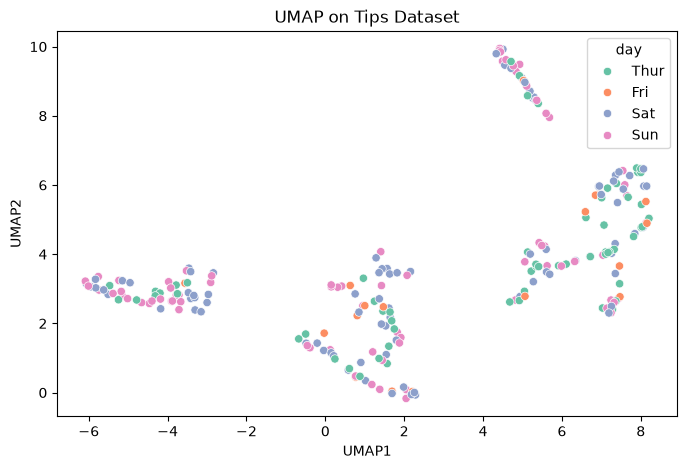

In [16]:
# 1. UMAP output ko DataFrame me convert karein
df_umap = pd.DataFrame(x, columns=['UMAP1', 'UMAP2'])

# 2. Target / Category column add karein (jaise 'day' ya 'time')
df_umap['day'] = df['day']

# 3. Scatter plot create karein
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_umap, 
    x='UMAP1', 
    y='UMAP2', 
    hue='day', 
    palette='Set2'
)
plt.title('UMAP on Tips Dataset')
plt.show()